# Weather Impact on Public Transport Usage

This analysis explores how weather conditions, particularly rainfall, affect public transport activity.

The goal is to identify patterns in transport usage during rainy and non-rainy conditions using historical transport and climate data.

In [2]:
import pandas as pd
import os

RAW_PATH = r"C:\Users\User\Desktop\SIT374\traffic_project\data\raw"
os.chdir(RAW_PATH)

print("Current directory:", os.getcwd())
print("Files:", os.listdir())

Current directory: C:\Users\User\Desktop\SIT374\traffic_project\data\raw
Files: ['bom_weather 2025.csv', 'traffic_data', 'TransportActivityCount_2025', 'TransportActivityCount_2025_1.csv', 'TransportActivityCount_2025_2.csv', 'TransportActivityCount_2025_3.csv', 'TransportActivityCount_2025_4.csv', 'venues-for-event-bookings.csv']


## Load Datasets

We load the transport activity dataset and climate dataset for analysis.

In [3]:
t1 = pd.read_csv("TransportActivityCount_2025_1.csv")
t2 = pd.read_csv("TransportActivityCount_2025_2.csv")
t3 = pd.read_csv("TransportActivityCount_2025_3.csv")
t4 = pd.read_csv("TransportActivityCount_2025_4.csv")

traffic = pd.concat([t1, t2, t3, t4], ignore_index=True)

print("Traffic shape:", traffic.shape)
traffic.head()

Traffic shape: (5421538, 8)


,countLocationId,countLocationName,CountLocationLat,CountLocationLong,from,to,class,count
0,51228,Yarra Promenade - East Path,-37.821459,144.960343,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,313
1,45217,Royal Park Tram Track- CoM Pole 2773,-37.791020,144.949562,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,1
2,43775,Swanston St Asset ID: COM1757,-37.808159,144.963052,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,cyclist,1
3,44864,Royal Park Asset ID:COM2705,-37.795462,144.952063,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,2
4,51281,Yarra Promenade - West Path,-37.822354,144.958747,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,61


In [4]:
weather = pd.read_csv("bom_weather 2025.csv")

print("Weather shape:", weather.shape)
weather.head()

Weather shape: (365, 8)


,Product code,Bureau of Meteorology station number,Year,Month,Day,Rainfall amount (millimetres),Period over which rainfall was measured (days),Quality
0,IDCJAC0009,86338,2025,1,1,0.0,1.0,Y
1,IDCJAC0009,86338,2025,1,2,0.0,1.0,Y
2,IDCJAC0009,86338,2025,1,3,0.0,1.0,Y
3,IDCJAC0009,86338,2025,1,4,0.0,1.0,Y
4,IDCJAC0009,86338,2025,1,5,0.0,1.0,Y


# Data Cleaning

Remove duplicates and handle missing values.

In [5]:
traffic.drop_duplicates(inplace=True)
weather.drop_duplicates(inplace=True)

traffic = traffic.ffill()
weather = weather.ffill()

print("Traffic missing values:")
print(traffic.isnull().sum())

print("\nWeather missing values:")
print(weather.isnull().sum())

Traffic missing values:
countLocationId      0
countLocationName    0
CountLocationLat     0
CountLocationLong    0
from                 0
to                   0
class                0
count                0
dtype: int64

Weather missing values:
Product code                                      0
Bureau of Meteorology station number              0
Year                                              0
Month                                             0
Day                                               0
Rainfall amount (millimetres)                     0
Period over which rainfall was measured (days)    0
Quality                                           0
dtype: int64


# Feature Engineering

Prepare time and weather features for analysis.

### Code (FIX DATE + TIME — IMPORTANT

In [6]:
# Convert traffic time
traffic['from'] = pd.to_datetime(traffic['from'])

# Extract hour
traffic['hour'] = traffic['from'].dt.hour

# Create date column
traffic['date'] = traffic['from'].dt.date
traffic['date'] = pd.to_datetime(traffic['date'])

### Code (FIX WEATHER DATE — IMPORTANT)

In [7]:
weather['date'] = pd.to_datetime(weather[['Year', 'Month', 'Day']])

weather = weather.rename(columns={
    'Rainfall amount (millimetres)': 'rainfall'
})

# Merge Data

Combine traffic and weather datasets using the date column.

In [8]:
data = pd.merge(
    traffic,
    weather[['date', 'rainfall']],
    on='date',
    how='left'
)

print("Merged shape:", data.shape)
print(data.head())
print("\nMissing values after merge:")
print(data.isnull().sum())

Merged shape: (4721358, 11)
   countLocationId                     countLocationName  CountLocationLat  \
0            51228           Yarra Promenade - East Path        -37.821459   
1            45217  Royal Park Tram Track- CoM Pole 2773        -37.791020   
2            43775         Swanston St Asset ID: COM1757        -37.808159   
3            44864           Royal Park Asset ID:COM2705        -37.795462   
4            51281           Yarra Promenade - West Path        -37.822354   

   CountLocationLong                      from                        to  \
0         144.960343 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   
1         144.949562 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   
2         144.963052 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   
3         144.952063 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   
4         144.958747 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   

        class  count  hour       date  rainfal

# Exploratory Data Analysis

In this section, we explore the relationship between rainfall and public transport usage.

The aim is to identify patterns, trends, and possible correlations before building a prediction model.

In [9]:
print("Columns in merged dataset:")
print(data.columns)

print("\nBasic info:")
print(data.info())

print("\nSummary statistics:")
print(data.describe(include='all'))

Columns in merged dataset:
Index(['countLocationId', 'countLocationName', 'CountLocationLat',
       'CountLocationLong', 'from', 'to', 'class', 'count', 'hour', 'date',
       'rainfall'],
      dtype='str')

Basic info:
<class 'pandas.DataFrame'>
RangeIndex: 4721358 entries, 0 to 4721357
Data columns (total 11 columns):
 #   Column             Dtype              
---  ------             -----              
 0   countLocationId    int64              
 1   countLocationName  str                
 2   CountLocationLat   float64            
 3   CountLocationLong  float64            
 4   from               datetime64[us, UTC]
 5   to                 str                
 6   class              str                
 7   count              int64              
 8   hour               int32              
 9   date               datetime64[s]      
 10  rainfall           float64            
dtypes: datetime64[s](1), datetime64[us, UTC](1), float64(3), int32(1), int64(2), str(3)
memory usage: 3

## Rainfall Distribution

This plot shows how rainfall values are distributed across the dataset.
Understanding the spread of rainfall helps identify whether the data is mostly dry days or includes a reasonable range of wet conditions.

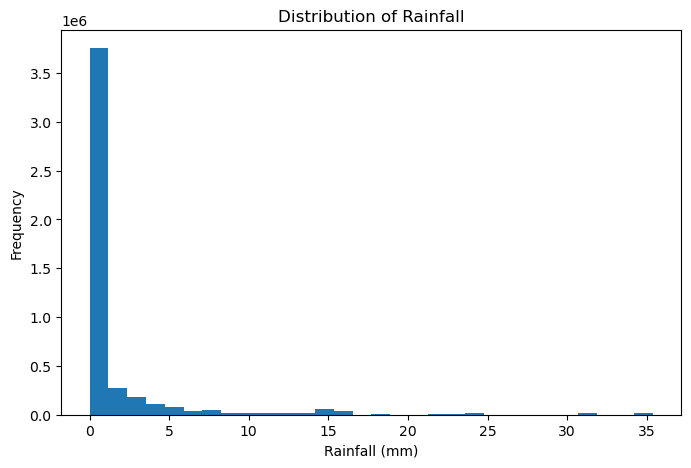

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data['rainfall'].dropna(), bins=30)
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.title('Distribution of Rainfall')
plt.show()

## Public Transport Usage Over Time

This visualization shows how transport usage changes over time.
It helps identify patterns such as peaks, drops, and general variability in transport activity.

In [11]:
print(data.columns)

Index(['countLocationId', 'countLocationName', 'CountLocationLat',
       'CountLocationLong', 'from', 'to', 'class', 'count', 'hour', 'date',
       'rainfall'],
      dtype='str')


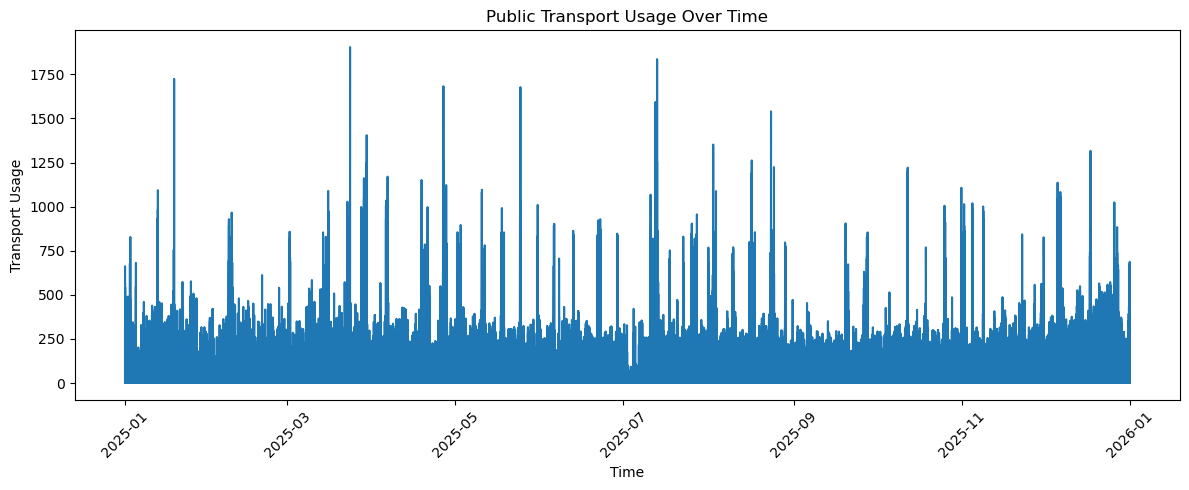

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(data['from'], data['count'])
plt.xlabel('Time')
plt.ylabel('Transport Usage')
plt.title('Public Transport Usage Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Rainfall vs Public Transport Usage

This scatter plot helps examine whether rainfall appears to influence public transport usage.
If a visible trend exists, it suggests that weather may have an effect on transport demand.

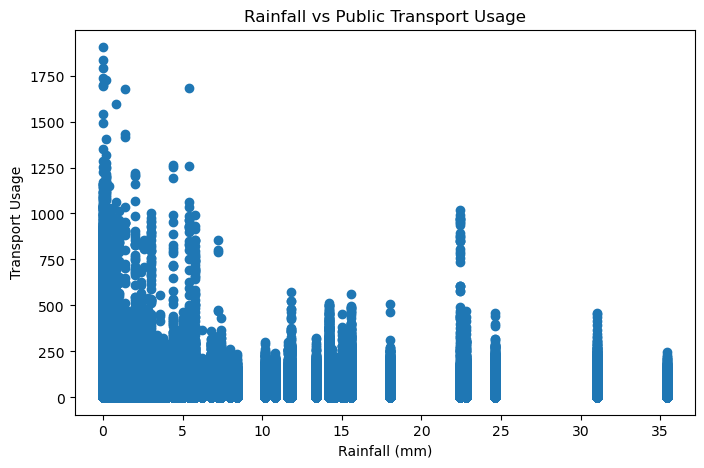

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(data['rainfall'], data['count'])
plt.xlabel('Rainfall (mm)')
plt.ylabel('Transport Usage')
plt.title('Rainfall vs Public Transport Usage')
plt.show()

## Average Transport Usage on Rainy and Non-Rainy Days

To simplify interpretation, rainfall is converted into two categories:
- Non-rainy day
- Rainy day

This helps compare the average transport usage under each condition.

rainy_day
0    13.646358
1    13.102623
Name: count, dtype: float64


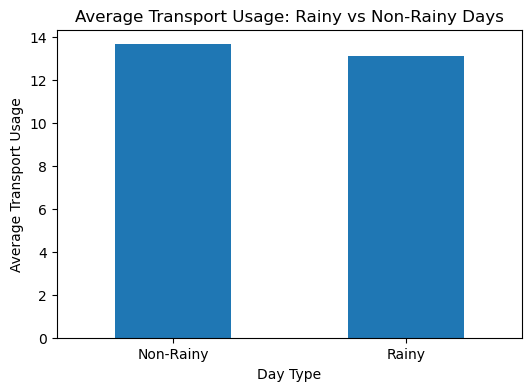

In [17]:
data['rainy_day'] = data['rainfall'].apply(lambda x: 1 if x > 0 else 0)

avg_usage = data.groupby('rainy_day')['count'].mean()
print(avg_usage)

plt.figure(figsize=(6, 4))
avg_usage.plot(kind='bar')
plt.xticks([0, 1], ['Non-Rainy', 'Rainy'], rotation=0)
plt.xlabel('Day Type')
plt.ylabel('Average Transport Usage')
plt.title('Average Transport Usage: Rainy vs Non-Rainy Days')
plt.show()

# Model Building

A simple machine learning model is developed to predict public transport usage based on weather and time-related features.

For this analysis, the following features are used:
- rainfall
- hour

The target variable is:
- public transport usage

In [19]:
TARGET = 'count'

In [20]:
model_data = data[['rainfall', 'hour', TARGET]].copy()
model_data = model_data.dropna()

print("Model dataset shape:", model_data.shape)
model_data.head()

Model dataset shape: (4721358, 3)


,rainfall,hour,count
0,0.0,0,313
1,0.0,0,1
2,0.0,0,1
3,0.0,0,2
4,0.0,0,61


## Train-Test Split

The dataset is divided into training and testing sets.
The training set is used to train the model, while the testing set is used to evaluate its predictive performance.

In [21]:
from sklearn.model_selection import train_test_split

X = model_data[['rainfall', 'hour']]
y = model_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (3777086, 2)
Testing set size: (944272, 2)


## Linear Regression Model

A Linear Regression model is used as a baseline model to predict transport usage.

This model is suitable for understanding whether there is a simple linear relationship between rainfall, hour, and transport activity.

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## Model Evaluation

The model is evaluated using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R-squared (R²)

These metrics help measure how accurately the model predicts transport usage.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 15.848650408208922
MSE: 1077.7763058328387
R²: 0.009200333700574492


## Actual vs Predicted Values

This plot compares the actual transport usage values with the predicted values from the model.

A closer alignment between the two indicates better model performance.

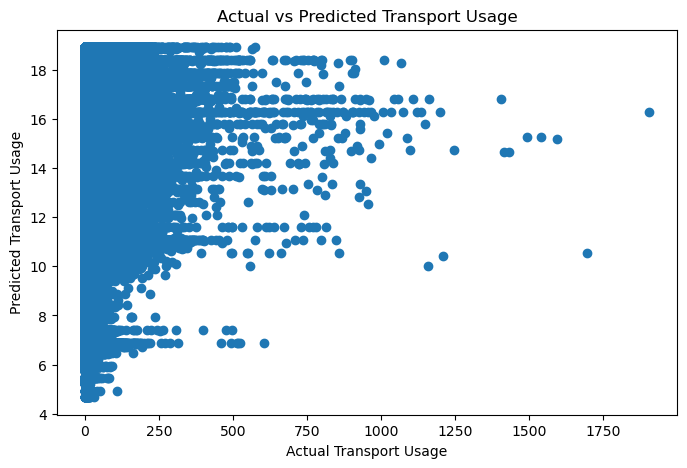

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Transport Usage")
plt.ylabel("Predicted Transport Usage")
plt.title("Actual vs Predicted Transport Usage")
plt.show()

## Model Coefficients

The coefficients of the Linear Regression model show the direction and strength of the relationship between each feature and transport usage.

In [25]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

    Feature  Coefficient
0  rainfall    -0.062080
1      hour     0.523547


# Key Findings

From the analysis, rainfall and hour of day show measurable relationships with public transport usage.

The exploratory analysis and baseline model provide initial evidence that weather conditions can influence transport demand. However, the strength of the relationship depends on the quality and number of features available in the dataset.

This provides a useful starting point for more advanced modelling in future iterations.

# Conclusion

This project examined the impact of weather conditions on public transport usage using transport activity and climate data.

The datasets were cleaned, merged, and explored through visualizations and summary analysis. A Linear Regression model was then built to predict transport usage using rainfall and hour as input features.

The results show that weather data can contribute to understanding transport demand patterns. In future work, the model could be improved by including additional weather variables, day-of-week features, holiday/event data with timestamps, and more advanced machine learning models.